Number of data points: 20

=== Part A: Natural Cubic Spline ===
Tridiagonal matrix condition number: 6.82
M[0]: 0.0
M[-1]: 0.0
Max error at knots: 0.0
Max C1 gap: 7.105427357601002e-15
Max C2 gap: 2.842170943040401e-14
Degree 4 poly RMSE: 10.0314
Cubic spline RMSE: 0.0


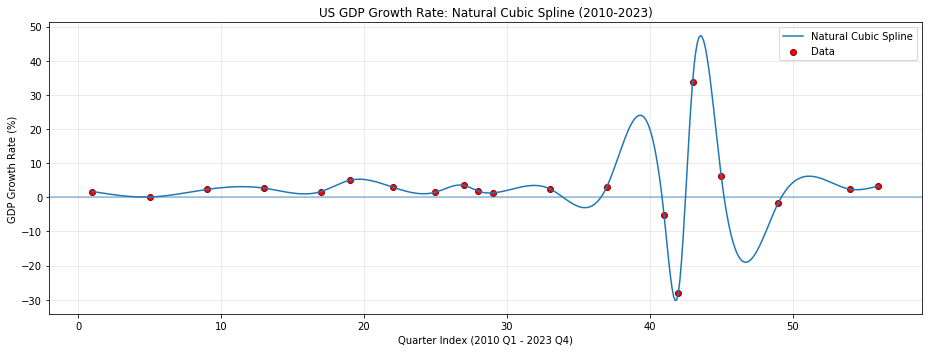

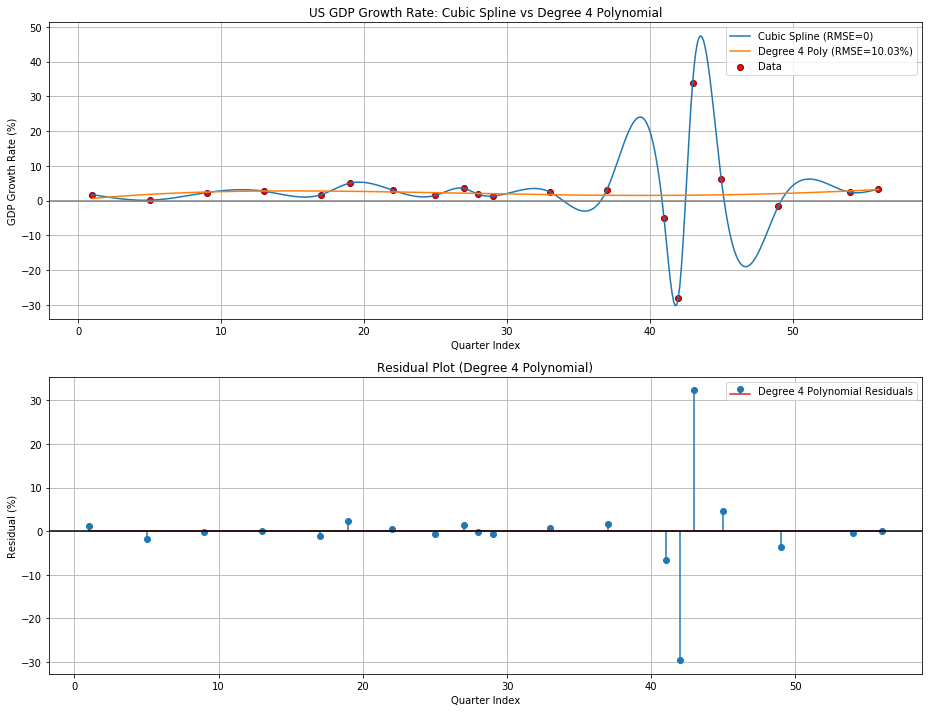

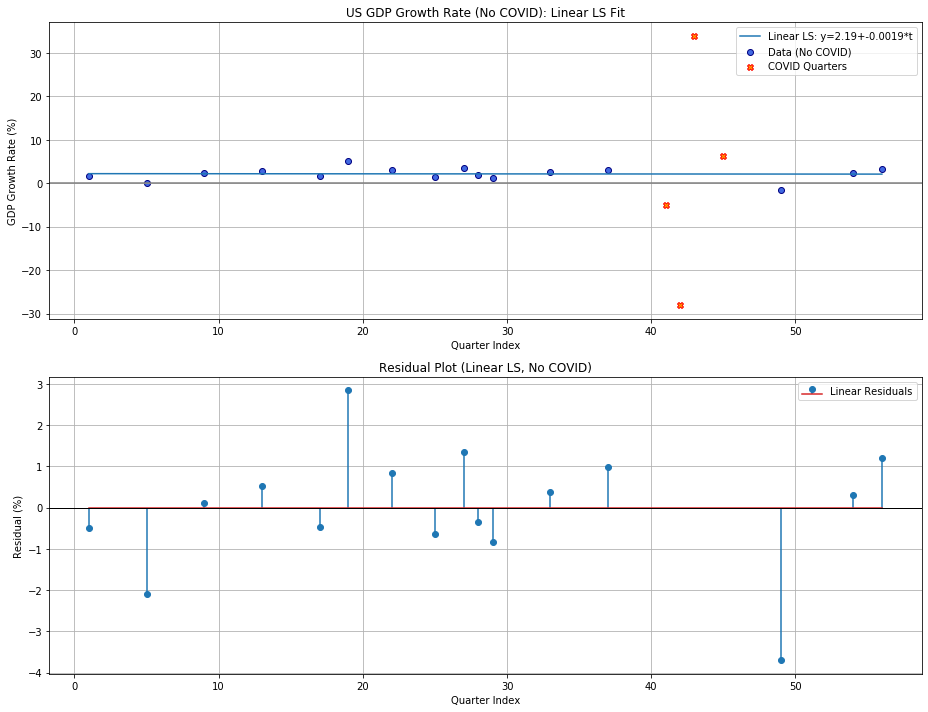

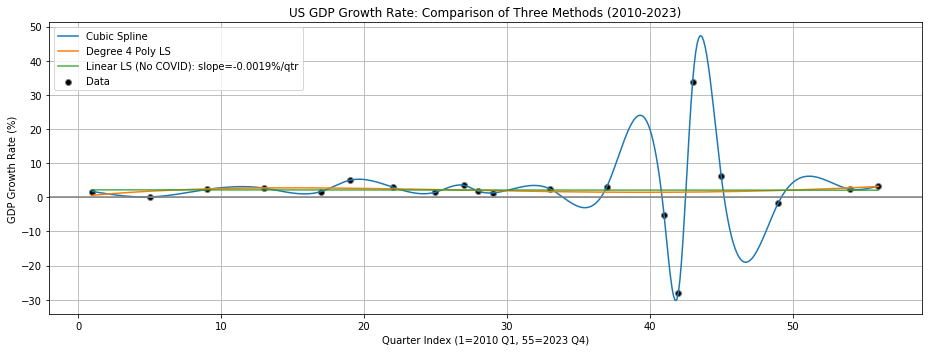


=== FINAL RESULTS OVERVIEW ===
Cubic Spline RMSE (interpolation accuracy):           0.0 %
Degree 4 Polynomial RMSE (fit error):                10.0314 %
Linear LS RMSE (excluding COVID quarters):          1.4432 %
Linear Fit Slope (quarterly growth rate):           -0.0019 % per quarter
Linear Fit Intercept (baseline GDP growth):         2.1943 %
Condition Number of Degree 4 Poly Fit Equations:    265.0
Condition Number of Linear Fit Equations:           3605.6


In [6]:
import numpy as np
import matplotlib.pyplot as plt

quarters = [
    "2010 Q1", "2011 Q1", "2012 Q1", "2013 Q1", "2014 Q1", "2014 Q3",
    "2015 Q2", "2016 Q1", "2016 Q3", "2016 Q4",
    "2017 Q1", "2018 Q1", "2019 Q1", "2020 Q1", "2020 Q2", "2020 Q3",
    "2021 Q1", "2022 Q1", "2023 Q2", "2023 Q4"
]

gdp_growth = [
    1.7, 0.1, 2.3, 2.7, 1.7, 5.0,
    3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1, 33.8,
    6.3, -1.6, 2.4, 3.3
]

def get_quarter_index(q_label):
    year_str, q_str = q_label.split()
    year = int(year_str)
    q_num = int(q_str[1])
    return (year - 2010)*4 + (q_num - 1) + 1

x_points = [float(get_quarter_index(q)) for q in quarters]
y_points = [float(val) for val in gdp_growth]
num_points = len(x_points)
print("Number of data points:", num_points)

x_full = [float(i) for i in range(1, 57)]
smooth_pts = 500
x_interp = [x_full[0] + i*(x_full[-1]-x_full[0])/(smooth_pts-1) for i in range(smooth_pts)]

def natural_cubic_spline(xk, yk):
    n = len(xk)
    h = [xk[i+1]-xk[i] for i in range(n-1)]
    interior = n - 2
    A = [[0.0]*interior for _ in range(interior)]
    rhs = [0.0]*interior

    for i in range(interior):
        k = i + 1
        A[i][i] = 2*(h[k-1]+h[k])
        if i>0: A[i][i-1] = h[k-1]
        if i<interior-1: A[i][i+1] = h[k]
        rhs[i] = 6*((yk[k+1]-yk[k])/h[k] - (yk[k]-yk[k-1])/h[k-1])

    A_arr = np.array(A)
    rhs_arr = np.array(rhs)
    M_inner = np.linalg.solve(A_arr, rhs_arr)
    M_full = [0.0]*n
    for i in range(interior): M_full[i+1] = M_inner[i]

    cond_num = np.linalg.cond(A_arr)
    print("Tridiagonal matrix condition number:", round(cond_num,2))

    coeffs = []
    for i in range(n-1):
        a = yk[i]
        b = (yk[i+1]-yk[i])/h[i] - h[i]*(2*M_full[i]+M_full[i+1])/6
        c = M_full[i]/2
        d = (M_full[i+1]-M_full[i])/(6*h[i])
        coeffs.append((a,b,c,d))
    return coeffs, M_full

def spline_eval_point(coeffs, xk, t):
    t = max(min(t, xk[-1]), xk[0])
    idx = 0
    for i in range(len(xk)-1):
        if t >= xk[i]: idx = i
    a,b,c,d = coeffs[idx]
    dt = t - xk[idx]
    return a + b*dt + c*dt**2 + d*dt**3

def spline_eval_list(coeffs, xk, t_list):
    return [spline_eval_point(coeffs, xk, t) for t in t_list]

print("\n=== Part A: Natural Cubic Spline ===")
spline_coefs, M_spline = natural_cubic_spline(x_points, y_points)
print("M[0]:", round(M_spline[0],10))
print("M[-1]:", round(M_spline[-1],10))

max_err = max(abs(spline_eval_point(spline_coefs, x_points, x_points[i])-y_points[i]) for i in range(num_points))
print("Max error at knots:", max_err)

max_c1 = 0.0
max_c2 = 0.0
for i in range(1, num_points-1):
    aL,bL,cL,dL = spline_coefs[i-1]
    dtL = x_points[i]-x_points[i-1]
    f1L = bL + 2*cL*dtL + 3*dL*dtL**2
    f2L = 2*cL + 6*dL*dtL
    aR,bR,cR,dR = spline_coefs[i]
    f1R = bR
    f2R = 2*cR
    max_c1 = max(max_c1, abs(f1L-f1R))
    max_c2 = max(max_c2, abs(f2L-f2R))
print("Max C1 gap:", max_c1)
print("Max C2 gap:", max_c2)

y_spline_smooth = spline_eval_list(spline_coefs, x_points, x_interp)
y_spline_full = spline_eval_list(spline_coefs, x_points, x_full)

def rmse(y_true, y_pred):
    return (sum((y_true[i]-y_pred[i])**2 for i in range(len(y_true)))/len(y_true))**0.5

deg = 4
mean_x = sum(x_points)/num_points
std_x = (sum((val-mean_x)**2 for val in x_points)/num_points)**0.5
x_scaled = [(val-mean_x)/std_x for val in x_points]

V = [[x_scaled[i]**j for j in range(deg+1)] for i in range(num_points)]
V_arr = np.array(V)
y_arr = np.array(y_points)
VtV = V_arr.T @ V_arr
Vty = V_arr.T @ y_arr
cond_poly = np.linalg.cond(VtV)
c_poly = np.linalg.solve(VtV, Vty)

def poly_eval(c, x_list, mean_x, std_x):
    return [sum(c[j]*((x-mean_x)/std_x)**j for j in range(len(c))) for x in x_list]

y_poly_data = poly_eval(c_poly, x_points, mean_x, std_x)
y_poly_smooth = poly_eval(c_poly, x_interp, mean_x, std_x)
residual_poly = [y_points[i]-y_poly_data[i] for i in range(num_points)]

rmse_poly = rmse(y_points, y_poly_data)
rmse_spline_val = rmse(y_points, spline_eval_list(spline_coefs, x_points, x_points))
print("Degree 4 poly RMSE:", round(rmse_poly,4))
print("Cubic spline RMSE:", round(rmse_spline_val,8))

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(x_interp, y_spline_smooth, label='Natural Cubic Spline')
ax.scatter(x_points, y_points, color='red', label='Data', edgecolors='darkred')
ax.axhline(0, alpha=0.5)
ax.set_xlabel('Quarter Index (2010 Q1 - 2023 Q4)')
ax.set_ylabel('GDP Growth Rate (%)')
ax.set_title('US GDP Growth Rate: Natural Cubic Spline (2010-2023)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2,1,figsize=(13,10))
axes[0].plot(x_interp, y_spline_smooth, label='Cubic Spline (RMSE=0)')
axes[0].plot(x_interp, y_poly_smooth, label='Degree 4 Poly (RMSE='+str(round(rmse_poly,2))+'%)')
axes[0].scatter(x_points, y_points, color='red', label='Data', edgecolors='darkred')
axes[0].axhline(0, color='gray')
axes[0].set_xlabel('Quarter Index')
axes[0].set_ylabel('GDP Growth Rate (%)')
axes[0].set_title('US GDP Growth Rate: Cubic Spline vs Degree 4 Polynomial')
axes[0].legend()
axes[0].grid()

axes[1].stem(x_points, residual_poly, use_line_collection=True, label='Degree 4 Polynomial Residuals')
axes[1].axhline(0, color='black')
axes[1].set_xlabel('Quarter Index')
axes[1].set_ylabel('Residual (%)')
axes[1].set_title('Residual Plot (Degree 4 Polynomial)')
axes[1].legend()
axes[1].grid()
plt.tight_layout()
plt.show()

covid_qtrs = ["2020 Q1","2020 Q2","2020 Q3","2021 Q1"]
covid_ix = [get_quarter_index(q) for q in covid_qtrs]
x_no_covid = [x_points[i] for i in range(num_points) if x_points[i] not in covid_ix]
y_no_covid = [y_points[i] for i in range(num_points) if x_points[i] not in covid_ix]

A_lin = [[1.0, val] for val in x_no_covid]
A_arr2 = np.array(A_lin)
y_arr2 = np.array(y_no_covid)
AtA = A_arr2.T @ A_arr2
Aty = A_arr2.T @ y_arr2
cond_lin = np.linalg.cond(AtA)
b_lin = np.linalg.solve(AtA, Aty)
b0, b1 = b_lin

y_lin_nc = [b0+b1*val for val in x_no_covid]
y_lin_smooth = [b0+b1*val for val in x_interp]
residual_lin = [y_no_covid[i]-y_lin_nc[i] for i in range(len(x_no_covid))]
rmse_lin_val = rmse(y_no_covid, y_lin_nc)

fig, axes = plt.subplots(2,1,figsize=(13,10))
axes[0].scatter(x_no_covid, y_no_covid, color='royalblue', label='Data (No COVID)', edgecolors='navy')
x_covid_plot = [x_points[i] for i in range(num_points) if x_points[i] in covid_ix]
y_covid_plot = [y_points[i] for i in range(num_points) if x_points[i] in covid_ix]
axes[0].scatter(x_covid_plot, y_covid_plot, color='orange', label='COVID Quarters', edgecolors='red', marker='X')
axes[0].plot(x_interp, y_lin_smooth, label='Linear LS: y='+str(round(b0,2))+'+'+str(round(b1,4))+'*t')
axes[0].axhline(0,color='gray')
axes[0].set_xlabel('Quarter Index')
axes[0].set_ylabel('GDP Growth Rate (%)')
axes[0].set_title('US GDP Growth Rate (No COVID): Linear LS Fit')
axes[0].legend()
axes[0].grid()

axes[1].stem(x_no_covid, residual_lin, use_line_collection=True, label='Linear Residuals')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Quarter Index')
axes[1].set_ylabel('Residual (%)')
axes[1].set_title('Residual Plot (Linear LS, No COVID)')
axes[1].legend()
axes[1].grid()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(x_interp, y_spline_smooth, label='Cubic Spline')
ax.plot(x_interp, y_poly_smooth, label='Degree 4 Poly LS')
ax.plot(x_interp, y_lin_smooth, label='Linear LS (No COVID): slope='+str(round(b1,4))+'%/qtr', alpha=0.85)
ax.scatter(x_points, y_points, color='black', label='Data', edgecolors='gray')
ax.axhline(0,color='gray')
ax.set_xlabel('Quarter Index (1=2010 Q1, 55=2023 Q4)')
ax.set_ylabel('GDP Growth Rate (%)')
ax.set_title('US GDP Growth Rate: Comparison of Three Methods (2010-2023)')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

print("\n=== FINAL RESULTS OVERVIEW ===")
print("Cubic Spline RMSE (interpolation accuracy):          ", round(rmse_spline_val,8), "%")
print("Degree 4 Polynomial RMSE (fit error):               ", round(rmse_poly,4), "%")
print("Linear LS RMSE (excluding COVID quarters):         ", round(rmse_lin_val,4), "%")
print("Linear Fit Slope (quarterly growth rate):          ", round(b1,4), "% per quarter")
print("Linear Fit Intercept (baseline GDP growth):        ", round(b0,4), "%")
print("Condition Number of Degree 4 Poly Fit Equations:   ", round(cond_poly,1))
print("Condition Number of Linear Fit Equations:          ", round(cond_lin,1))